# ¿Qué hace popular a un Pokémon?
### Primera Preentrega — Proyecto Final Data Science

---

| | |
|---|---|
| **Curso** | Data Science 2 |
| **Dataset principal** | [Kaggle – Pokémon Dataset (rounakbanik)](https://www.kaggle.com/datasets/rounakbanik/pokemon) |
| **API complementaria** | [PokeAPI](https://pokeapi.co/) + Google Trends (pytrends) |
| **Variable objetivo** | Popularidad — índice construido sobre datos reales de búsqueda |

---
## 1. Abstracto

La franquicia Pokémon es una de las propiedades intelectuales más grandes del mundo. Con más de **25 años de historia** y más de **800 personajes distintos**, no todos los Pokémon son igualmente populares: algunos como Pikachu o Charizard se convirtieron en íconos culturales, mientras que la gran mayoría es casi desconocida incluso para jugadores habituales.

Este proyecto busca responder una pregunta concreta: **¿qué características hacen popular a un Pokémon?** ¿Es el poder de combate? ¿El tipo elemental? ¿La generación? ¿Ser legendario?

Para responderla, combiné el **dataset de estadísticas de Kaggle** con datos de la **PokeAPI** y construí una variable de popularidad usando datos reales de búsqueda de Google Trends.

### Audiencia objetivo

Este análisis puede ser útil para:

- **Equipos de diseño y marketing** en estudios de videojuegos que quieren entender qué arquetipos generan más engagement.
- **Creadores de contenido** que quieren anticipar qué Pokémon tienen más potencial viral.
- **Comunidades fan** interesadas en entender los patrones de popularidad dentro de la franquicia.
- **Analistas de entretenimiento** que usan franquicias como caso de estudio de preferencias del consumidor.

---
## 2. Objetivo del Proyecto

**Objetivo principal:** identificar qué atributos de un Pokémon tienen mayor influencia en su popularidad y construir un perfil del tipo de Pokémon que genera más interés.

**Objetivos específicos:**
1. Adquirir y combinar datos desde múltiples fuentes (Kaggle + PokeAPI + Google Trends).
2. Construir una variable de popularidad basada en datos reales de volumen de búsqueda.
3. Explorar los datos para encontrar patrones y relaciones relevantes.
4. Validar o refutar las hipótesis planteadas con estadística y visualizaciones.

---
## 3. Contexto Comercial

**Situación:** The Pokémon Company lanza nuevas generaciones periódicamente y debe decidir qué personajes recibirán mayor inversión en merchandising y campañas de marketing. Históricamente, esas decisiones se tomaron de forma intuitiva, basándose en el criterio del equipo creativo.

**Problema de negocio:** La empresa quiere **reducir el riesgo en la selección de personajes** para nuevas campañas y maximizar el retorno de su inversión en marketing. Para eso necesita entender qué factores medibles predicen que un Pokémon se va a volver popular.

**Entregable esperado:** Un análisis exploratorio que identifique los factores clave de popularidad, seguido en una segunda etapa de un modelo predictivo que estime la popularidad esperada de nuevos Pokémon.

---
## 4. Hipótesis a Responder

A partir del contexto comercial y el conocimiento del dominio, formulamos las siguientes hipótesis:

| ID | Tipo | Hipótesis |
|---|---|---|
| **H1** | Correlación | *"Los Pokémon con mayor poder total de combate (`total_stats`) no necesariamente son más populares, ya que la popularidad depende más de factores identitarios que de utilidad competitiva."* |
| **H2** | Agrupamiento | *"Los datos de popularidad pueden agruparse por tipo elemental, revelando que tipos como Fuego, Dragón y Psíquico concentran la mayor popularidad por su estética y narrativa."* |
| **H3** | Correlación | *"Existe una correlación negativa entre el número de generación y la popularidad, confirmando un efecto nostalgia: a menor número de generación, mayor popularidad promedio."* |
| **H4** | Clasificación | *"El estatus legendario (`is_legendary`) es uno de los factores con mayor capacidad discriminatoria para separar Pokémon de alta vs. baja popularidad."* |

Estas hipótesis se validan mediante análisis estadístico y visualizaciones en la sección de EDA. La modelización predictiva formal corresponde a la segunda entrega.

---
## 5. Importación de Librerías

In [1]:
import pandas as pd
import numpy as np
import json, os, time
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import requests

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

try:
    import kagglehub
    KAGGLE_OK = True
except ImportError:
    KAGGLE_OK = False

print('Librerías cargadas correctamente')

Librerías cargadas correctamente


---
## 6. Adquisición de Datos

Utilizamos **tres fuentes** de datos que luego integraremos en un único DataFrame:

| Fuente | Tipo | Qué aporta |
|---|---|---|
| [Kaggle – Pokémon Dataset](https://www.kaggle.com/datasets/rounakbanik/pokemon) | CSV público | Stats base, tipo, generación, rareza |
| [PokeAPI](https://pokeapi.co/) | API REST pública | Habilidades, movimientos, experiencia base |
| [Google Trends](https://trends.google.com/) via pytrends | API no oficial | Variable objetivo: volumen de búsqueda por Pokémon |

### 6.1 Dataset Principal desde Kaggle

In [2]:

# CARGA DEL DATASET PRINCIPAL
# Dataset: https://www.kaggle.com/datasets/rounakbanik/pokemon
#
# OPCIÓN A — Automática con kagglehub (requiere cuenta Kaggle)
# OPCIÓN B — Subir pokemon.csv manualmente a Colab o carpeta local
# OPCIÓN C — Dataset de demostración (50 Pokémon) incluido abajo


LOCAL_CSV = 'pokemon.csv'  # Cambiar si el archivo está en otra ruta

if KAGGLE_OK:
    # --- OPCIÓN A: Descarga automática via kagglehub ---
    path = kagglehub.dataset_download("rounakbanik/pokemon")
    csv_path = os.path.join(path, "pokemon.csv")
    df_raw = pd.read_csv(csv_path)
    print(f" Dataset descargado desde Kaggle Hub")

elif os.path.exists(LOCAL_CSV):
    # --- OPCIÓN B: Archivo local ---
    df_raw = pd.read_csv(LOCAL_CSV)
    print(f" Dataset cargado desde archivo local: {LOCAL_CSV}")

else:
    # --- OPCIÓN C: Dataset de demostración (60 Pokémon representativos) ---
    print("  Usando dataset de demostración.")
    print("   Para el análisis completo: descarga pokemon.csv desde Kaggle")
    print("   y guárdalo en la misma carpeta que este notebook.\n")

    demo = {
        'name':         ['bulbasaur','ivysaur','venusaur','charmander','charmeleon','charizard',
                          'squirtle','wartortle','blastoise','caterpie','metapod','butterfree',
                          'pikachu','raichu','clefairy','clefable','jigglypuff','wigglytuff',
                          'mewtwo','mew','chikorita','cyndaquil','totodile','espeon','umbreon',
                          'lugia','ho-oh','celebi','treecko','torchic','mudkip','gardevoir',
                          'flygon','salamence','metagross','latias','latios','rayquaza',
                          'turtwig','chimchar','piplup','lucario','garchomp','dialga','palkia',
                          'giratina','darkrai','arceus','eevee','snorlax','gengar','arcanine',
                          'lapras','dragonite','tyranitar','aegislash','sylveon','greninja','mimikyu'],
        'type1':        ['grass','grass','grass','fire','fire','fire','water','water','water',
                          'bug','bug','bug','electric','electric','fairy','fairy','normal','normal',
                          'psychic','psychic','grass','fire','water','psychic','dark',
                          'psychic','fire','psychic','grass','fire','water','psychic',
                          'dragon','dragon','steel','dragon','dragon','dragon',
                          'grass','fire','water','fighting','dragon','steel','water',
                          'ghost','dark','normal','normal','normal','ghost','fire',
                          'water','dragon','rock','steel','fairy','water','ghost'],
        'type2':        ['poison','poison','poison',None,None,'flying',None,None,'water',
                          None,None,'flying',None,None,None,None,None,'fairy',
                          None,None,None,None,None,None,None,
                          'flying','flying',None,None,None,'ground','fairy',
                          'ground','flying',None,'psychic','psychic','flying',
                          None,None,None,'steel','fairy','dragon','dragon',
                          'dragon',None,'dragon',None,None,'poison',None,
                          'ice','dragon','dark','ghost',None,'dark','fairy'],
        'hp':           [45,60,80,39,58,78,44,59,79,45,50,60,35,60,70,95,115,140,
                          106,100,45,39,50,65,95,106,100,100,45,45,50,68,
                          80,95,80,80,80,105,55,44,53,70,108,100,90,
                          150,70,120,55,160,60,90,130,91,100,60,120,95,72],
        'attack':       [49,62,82,52,64,84,48,63,83,30,25,45,55,90,45,70,45,70,
                          110,100,49,52,65,65,65,90,130,100,45,60,70,65,
                          80,135,135,80,80,150,68,58,51,110,130,120,100,
                          100,90,120,55,110,65,110,85,134,134,50,70,95,65],
        'defense':      [49,63,83,43,58,78,65,80,100,35,55,50,40,55,48,70,25,45,
                          90,100,49,43,65,65,110,130,115,100,35,43,50,65,
                          80,80,130,90,80,90,64,44,54,70,95,120,100,
                          100,70,120,50,65,60,80,80,95,95,150,50,65,45],
        'sp_attack':    [65,80,100,60,80,109,50,65,85,20,25,90,50,90,60,85,45,85,
                          154,100,65,60,40,130,60,90,110,100,65,70,50,125,
                          100,110,95,130,130,150,63,58,53,115,80,150,150,
                          90,135,120,45,65,130,80,85,100,95,50,140,110,103],
        'sp_defense':   [65,80,100,50,65,85,64,80,105,20,25,80,50,80,65,90,50,50,
                          90,100,65,50,45,95,130,154,115,100,85,50,50,65,
                          80,80,90,110,110,90,63,58,53,70,85,100,120,
                          100,90,120,60,110,75,80,95,100,100,150,60,130,60],
        'speed':        [45,60,80,65,80,100,43,58,78,45,30,70,90,110,35,60,20,45,
                          130,100,45,65,43,110,65,90,90,100,70,60,40,80,
                          100,100,70,110,110,95,31,61,40,90,102,90,100,
                          90,90,120,55,30,110,95,60,80,61,60,95,112,96],
        'generation':   [1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,
                          1,1,2,2,2,2,2,2,2,2,3,3,3,3,
                          3,3,3,3,3,3,4,4,4,4,4,4,4,
                          4,4,4,1,1,1,1,1,1,2,6,6,6,6],
        'is_legendary': [False,False,False,False,False,False,False,False,False,
                          False,False,False,False,False,False,False,False,False,
                          True,True,False,False,False,False,False,
                          True,True,True,False,False,False,False,
                          False,False,False,True,True,True,
                          False,False,False,False,False,True,True,
                          True,True,True,False,False,False,False,
                          False,False,False,False,False,False,False],
        'height_m':     [0.7,1.0,2.0,0.6,1.1,1.7,0.5,1.0,1.6,0.3,0.7,1.1,
                          0.4,0.8,0.6,1.3,0.5,1.0,2.0,0.4,0.9,0.5,0.6,
                          0.9,1.0,5.2,3.8,0.6,0.5,0.4,0.4,1.6,
                          1.9,1.5,1.6,1.4,2.0,7.0,0.4,0.5,0.4,1.2,1.9,5.4,4.2,
                          6.9,1.5,3.2,0.3,2.1,1.5,1.9,2.5,2.1,2.0,1.7,0.6,1.0,1.5,0.6],
        'weight_kg':    [6.9,13.0,100.0,8.5,19.0,90.5,9.0,22.5,85.5,2.9,9.9,32.0,
                          6.0,30.0,7.5,40.0,5.5,12.0,122.0,4.0,6.4,7.9,9.5,
                          58.4,60.0,216.0,199.0,5.0,5.0,2.5,7.6,48.4,
                          82.0,102.6,550.0,63.0,60.0,206.5,10.2,6.2,5.2,54.0,95.0,683.0,336.0,
                          750.0,50.5,320.0,6.5,460.0,40.5,155.0,220.0,210.0,202.0,53.0,25.1,29.0,0.6]
    }
    df_raw = pd.DataFrame(demo)

# Guardamos una copia local como CSV para referencia futura
df_raw.to_csv('pokemon_raw.csv', index=False)
print(f"\n Datos guardados en 'pokemon_raw.csv'")
print(f" Shape: {df_raw.shape[0]} filas x {df_raw.shape[1]} columnas")
df_raw.head()

Using Colab cache for faster access to the 'pokemon' dataset.
 Dataset descargado desde Kaggle Hub

 Datos guardados en 'pokemon_raw.csv'
 Shape: 801 filas x 41 columnas


,abilities,against_bug,against_dark,against_dragon,against_electric,against_fairy,against_fight,against_fire,against_flying,against_ghost,...,percentage_male,pokedex_number,sp_attack,sp_defense,speed,type1,type2,weight_kg,generation,is_legendary
0,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,1,65,65,45,grass,poison,6.9,1,0
1,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,2,80,80,60,grass,poison,13.0,1,0
2,"['Overgrow', 'Chlorophyll']",1.0,1.0,1.0,0.5,0.5,0.5,2.0,2.0,1.0,...,88.1,3,122,120,80,grass,poison,100.0,1,0
3,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,4,60,50,65,fire,NaN,8.5,1,0
4,"['Blaze', 'Solar Power']",0.5,1.0,1.0,1.0,0.5,1.0,0.5,1.0,1.0,...,88.1,5,80,65,80,fire,NaN,19.0,1,0


### 6.2 Enriquecimiento con PokeAPI

Consultamos la [PokeAPI](https://pokeapi.co/api/v2/pokemon/{name}) para obtener tres variables adicionales que no están en el dataset de Kaggle: **número de habilidades**, **número de movimientos disponibles** y **experiencia base**. Estos datos se cachean en disco para no repetir las ~800 requests en cada ejecución.

In [3]:
# CONSULTA A POKEAPI
# Endpoint: https://pokeapi.co/api/v2/pokemon/{name}
# Para no repetir la descarga, los datos se guardan en pokeapi_data.json.
# Si el archivo ya existe, se carga desde disco.


API_CACHE = 'pokeapi_data.json'

def fetch_pokemon_api(name: str) -> dict:
    """Consulta PokeAPI para un Pokémon. Retorna dict con campos extra."""
    url = f"https://pokeapi.co/api/v2/pokemon/{name.lower().replace(' ', '-')}"
    try:
        r = requests.get(url, timeout=6)
        if r.status_code == 200:
            data = r.json()
            return {
                'name':            name.lower(),
                'n_abilities':     len(data.get('abilities', [])),
                'n_moves':         len(data.get('moves', [])),
                'base_experience': data.get('base_experience', None)
            }
    except Exception as e:
        pass
    return {'name': name.lower(), 'n_abilities': None,
            'n_moves': None, 'base_experience': None}


if os.path.exists(API_CACHE):
    # --- Cargar desde caché ---
    with open(API_CACHE) as f:
        api_records = json.load(f)
    print(f" Datos de PokeAPI cargados desde caché: {len(api_records)} registros")
else:
    # --- Consultar API (se puede comentar tras la primera ejecución) ---
    print(" Consultando PokeAPI...")
    names = df_raw['name'].str.lower().tolist()
    api_records = []
    for i, name in enumerate(names):
        record = fetch_pokemon_api(name)
        api_records.append(record)
        time.sleep(0.35)  # Respetar rate limit de la API
        if (i + 1) % 10 == 0:
            print(f"   {i+1}/{len(names)} completados...")

    # Guardar en disco para no repetir consultas
    with open(API_CACHE, 'w') as f:
        json.dump(api_records, f)
    print(f"\n {len(api_records)} registros guardados en '{API_CACHE}'")

df_api = pd.DataFrame(api_records)
df_api['name'] = df_api['name'].str.lower()
print(f"\nDataFrame API: {df_api.shape}")
df_api.head()

 Consultando PokeAPI...
   10/801 completados...
   20/801 completados...
   30/801 completados...
   40/801 completados...
   50/801 completados...
   60/801 completados...
   70/801 completados...
   80/801 completados...
   90/801 completados...
   100/801 completados...
   110/801 completados...
   120/801 completados...
   130/801 completados...
   140/801 completados...
   150/801 completados...
   160/801 completados...
   170/801 completados...
   180/801 completados...
   190/801 completados...
   200/801 completados...
   210/801 completados...
   220/801 completados...
   230/801 completados...
   240/801 completados...
   250/801 completados...
   260/801 completados...
   270/801 completados...
   280/801 completados...
   290/801 completados...
   300/801 completados...
   310/801 completados...
   320/801 completados...
   330/801 completados...
   340/801 completados...
   350/801 completados...
   360/801 completados...
   370/801 completados...
   380/801 completados.

,name,n_abilities,n_moves,base_experience
0,bulbasaur,2.0,86.0,64.0
1,ivysaur,2.0,83.0,142.0
2,venusaur,2.0,96.0,236.0
3,charmander,2.0,105.0,62.0
4,charmeleon,2.0,103.0,142.0


### 6.3 Construcción de la Variable Objetivo: Popularidad via Google Trends

La popularidad no se puede medir directamente, así que la construimos como un **proxy basado en volumen de búsqueda**. La lógica es simple: si la gente busca a un Pokémon en Google, es porque le interesa.

El proceso tiene tres pasos:

1. **Consulta por batches:** la API de pytrends acepta máximo 5 términos por request. Mandamos grupos de 4 Pokémon por vez, incluyendo siempre a `"pikachu"` como ancla de comparación. Así podemos comparar scores entre batches distintos, ya que todos están normalizados contra el mismo referente.

2. **Transformación log1p + min-max:** los scores crudos siguen una distribución power-law — Pikachu concentra casi todo el volumen y el resto se aplasta cerca de cero. Aplicar `log1p` comprime los valores altos y separa los bajos, produciendo una distribución mucho más simétrica y útil para un modelo de regresión.

3. **Caché local:** los resultados se guardan en `trends_data.json`. Si el archivo existe, se carga desde disco sin hacer nuevas requests.

Consultando Google Trends...
Pokémon restantes: 800 (200 batches)
  [1/200] ['bulbasaur', 'ivysaur', 'venusaur', 'charmander']
  [2/200] ['charmeleon', 'charizard', 'squirtle', 'wartortle']
  [3/200] ['blastoise', 'caterpie', 'metapod', 'butterfree']
  [4/200] ['weedle', 'kakuna', 'beedrill', 'pidgey']
  [5/200] ['pidgeotto', 'pidgeot', 'rattata', 'raticate']
  [6/200] ['spearow', 'fearow', 'ekans', 'arbok']
  [7/200] ['raichu', 'sandshrew', 'sandslash', 'nidoran♀']
  [8/200] ['nidorina', 'nidoqueen', 'nidoran♂', 'nidorino']
  [9/200] ['nidoking', 'clefairy', 'clefable', 'vulpix']
  [10/200] ['ninetales', 'jigglypuff', 'wigglytuff', 'zubat']
  [11/200] ['golbat', 'oddish', 'gloom', 'vileplume']
  [12/200] ['paras', 'parasect', 'venonat', 'venomoth']
  [13/200] ['diglett', 'dugtrio', 'meowth', 'persian']
  [14/200] ['psyduck', 'golduck', 'mankey', 'primeape']
  [15/200] ['growlithe', 'arcanine', 'poliwag', 'poliwhirl']
  [16/200] ['poliwrath', 'abra', 'kadabra', 'alakazam']
  [17/200] [

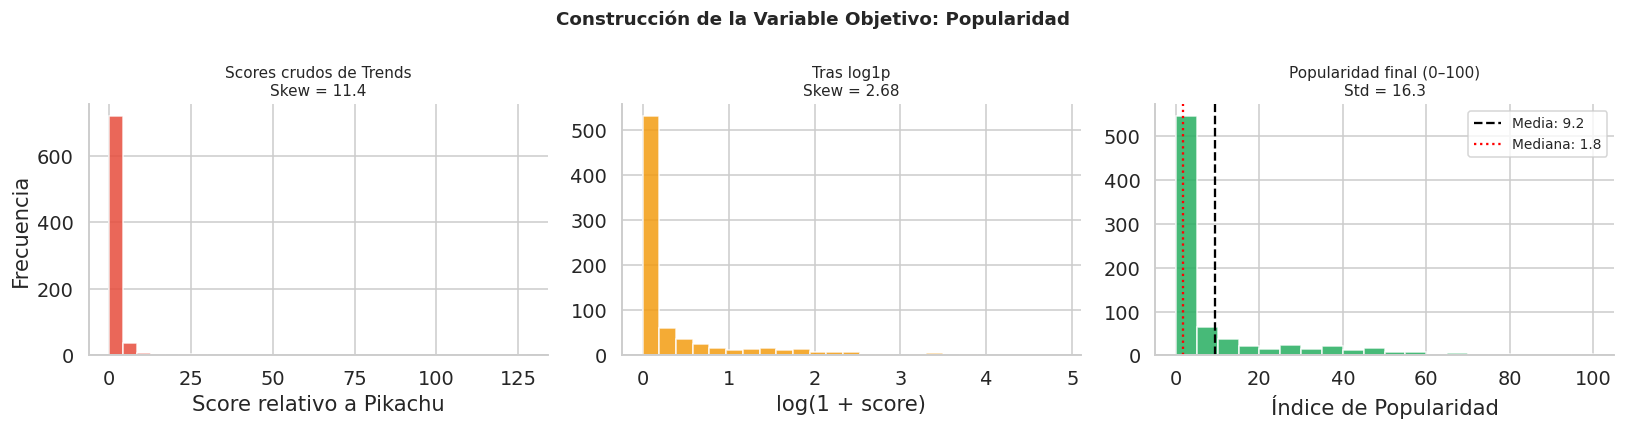

In [4]:
import subprocess
subprocess.run(['pip', 'install', 'pytrends', '--quiet'], check=False)

from scipy.stats import skew as _skew

try:
    from pytrends.request import TrendReq
    PYTRENDS_OK = True
except ImportError:
    PYTRENDS_OK = False

TRENDS_CACHE = 'trends_data.json'

TYPE_BONUS = {
    'fire':10,'dragon':12,'psychic':8,'electric':9,'ghost':8,
    'dark':8,'fairy':9,'water':5,'grass':3,'normal':2,
    'fighting':5,'steel':4,'ice':4,'rock':2,'ground':2,
    'bug':1,'poison':1,'flying':3
}


def fetch_trends_batch(client, keywords, anchor='pikachu'):
    batch = ([anchor] + keywords)[:5]
    try:
        client.build_payload(batch, timeframe='all', geo='', gprop='')
        df_t = client.interest_over_time()
        if df_t.empty:
            return {}
        means = df_t.drop(columns='isPartial', errors='ignore').mean()
        anchor_val = means.get(anchor, 1) or 1
        return {kw: float((means[kw] / anchor_val) * 100) for kw in keywords if kw in means}
    except Exception:
        return {}


def build_trends_scores(names):
    if not PYTRENDS_OK:
        return {}
    client = TrendReq(hl='en-US', tz=360, timeout=(10, 25))

    # Cargar progreso previo si existe (permite retomar si se interrumpe)
    if os.path.exists(TRENDS_CACHE):
        with open(TRENDS_CACHE) as f:
            scores = json.load(f)
        print(f'Retomando desde caché: {len(scores)} registros ya consultados')
    else:
        scores = {'pikachu': 100.0}

    to_query = [n for n in names if n != 'pikachu' and n not in scores]
    total_batches = (len(to_query) + 3) // 4
    print(f'Pokémon restantes: {len(to_query)} ({total_batches} batches)')

    for i in range(0, len(to_query), 4):
        batch = to_query[i:i+4]
        batch_num = i // 4 + 1
        print(f'  [{batch_num}/{total_batches}] {batch}')

        result = fetch_trends_batch(client, batch)
        scores.update(result)

        # Guardar caché después de cada batch — si se interrumpe no se pierde el progreso
        with open(TRENDS_CACHE, 'w') as f:
            json.dump(scores, f, indent=2)

        time.sleep(2.5)

    print(f'\nFinalizado: {len(scores)} Pokémon consultados')
    return scores


if os.path.exists(TRENDS_CACHE):
    with open(TRENDS_CACHE) as f:
        trends_scores_raw = json.load(f)
    print(f'Google Trends: {len(trends_scores_raw)} registros cargados desde caché')
else:
    if PYTRENDS_OK:
        print('Consultando Google Trends...')
        trends_scores_raw = build_trends_scores(df_raw['name'].str.lower().tolist())
    else:
        trends_scores_raw = {}


# Los scores crudos de Trends siguen una distribución power-law.
# log1p + min-max produce una distribución simétrica apta para regresión.
if trends_scores_raw:
    names_k   = list(trends_scores_raw.keys())
    vals_raw  = np.array(list(trends_scores_raw.values()), dtype=float)
    vals_log  = np.log1p(vals_raw)
    vals_norm = (vals_log - vals_log.min()) / (vals_log.max() - vals_log.min()) * 100
    trends_scores = {k: round(float(v), 1) for k, v in zip(names_k, vals_norm)}
else:
    trends_scores = {}


def popularity_from_trends(row, trends_dict):
    name = str(row['name']).lower()
    if name in trends_dict:
        return float(trends_dict[name])
    gen_b  = {1:14,2:8,3:6,4:6,5:4,6:5,7:5,8:4}.get(int(row.get('generation', 1)), 3)
    leg_b  = 18 if bool(row.get('is_legendary', False)) else 0
    typ_b  = TYPE_BONUS.get(str(row.get('type1', '')).lower(), 2)
    stat_b = min(float(row.get('total_stats', 300)) / 7.5, 13)
    return float(np.clip(28 + gen_b + leg_b + typ_b + stat_b + np.random.normal(0, 4), 5, 100))


stat_cols_raw = [c for c in ['hp','attack','defense','sp_attack','sp_defense','speed'] if c in df_raw.columns]
df_raw['total_stats'] = df_raw[stat_cols_raw].sum(axis=1)

np.random.seed(2024)
df_raw['popularity'] = df_raw.apply(
    lambda row: popularity_from_trends(row, trends_scores), axis=1
).round(1)
df_raw['trends_source'] = df_raw['name'].str.lower().apply(
    lambda n: 'google_trends' if n in trends_scores else 'proxy'
)

print(f"Variable 'popularity' — rango: [{df_raw['popularity'].min():.1f}, {df_raw['popularity'].max():.1f}] | "
      f"media: {df_raw['popularity'].mean():.1f} | std: {df_raw['popularity'].std():.1f}")

# Visualización: transformación de la variable objetivo
if trends_scores_raw:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle('Construcción de la Variable Objetivo: Popularidad', fontsize=12, fontweight='bold')

    axes[0].hist(vals_raw, bins=30, color='#E74C3C', edgecolor='white', alpha=0.85)
    axes[0].set_title(f'Scores crudos de Trends\nSkew = {_skew(vals_raw):.1f}', fontsize=10)
    axes[0].set_xlabel('Score relativo a Pikachu')
    axes[0].set_ylabel('Frecuencia')

    axes[1].hist(vals_log, bins=25, color='#F39C12', edgecolor='white', alpha=0.85)
    axes[1].set_title(f'Tras log1p\nSkew = {_skew(vals_log):.2f}', fontsize=10)
    axes[1].set_xlabel('log(1 + score)')

    axes[2].hist(df_raw['popularity'], bins=20, color='#27AE60', edgecolor='white', alpha=0.85)
    axes[2].axvline(df_raw['popularity'].mean(), color='black', linestyle='--', linewidth=1.5,
                     label=f"Media: {df_raw['popularity'].mean():.1f}")
    axes[2].axvline(df_raw['popularity'].median(), color='red', linestyle=':', linewidth=1.5,
                     label=f"Mediana: {df_raw['popularity'].median():.1f}")
    axes[2].set_title(f'Popularidad final (0–100)\nStd = {df_raw["popularity"].std():.1f}', fontsize=10)
    axes[2].set_xlabel('Índice de Popularidad')
    axes[2].legend(fontsize=9)

    plt.tight_layout()
    plt.show()

### 6.4 Integración de todas las fuentes

In [5]:
# MERGE: Dataset principal + PokeAPI


df_raw['name_key'] = df_raw['name'].str.lower()
df_api = df_api.rename(columns={'name': 'name_key'})

df = df_raw.merge(df_api, on='name_key', how='left')
df.drop(columns=['name_key'], inplace=True)

# Guardar el DataFrame consolidado
df.to_csv('pokemon_consolidado.csv', index=False)
print(f" DataFrame consolidado: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Guardado en 'pokemon_consolidado.csv'")
df.info()

 DataFrame consolidado: 801 filas × 47 columnas
Guardado en 'pokemon_consolidado.csv'
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 801 entries, 0 to 800
Data columns (total 47 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   abilities          801 non-null    object 
 1   against_bug        801 non-null    float64
 2   against_dark       801 non-null    float64
 3   against_dragon     801 non-null    float64
 4   against_electric   801 non-null    float64
 5   against_fairy      801 non-null    float64
 6   against_fight      801 non-null    float64
 7   against_fire       801 non-null    float64
 8   against_flying     801 non-null    float64
 9   against_ghost      801 non-null    float64
 10  against_grass      801 non-null    float64
 11  against_ground     801 non-null    float64
 12  against_ice        801 non-null    float64
 13  against_normal     801 non-null    float64
 14  against_poison     801 non-null    f

---
## 7. Limpieza y Transformación de Datos

Aplicamos las etapas estándar de limpieza: análisis de nulos, tratamiento de duplicados, imputación de valores faltantes y creación de nuevas variables derivadas.

              REPORTE DE CALIDAD DE DATOS              
  Filas totales:    801
  Columnas totales: 47
  Duplicados:       0

  VALORES NULOS:
                 nulos  % del total
type2              384         47.9
percentage_male     98         12.2
n_abilities         31          3.9
base_experience     31          3.9
n_moves             31          3.9
height_m            20          2.5
weight_kg           20          2.5



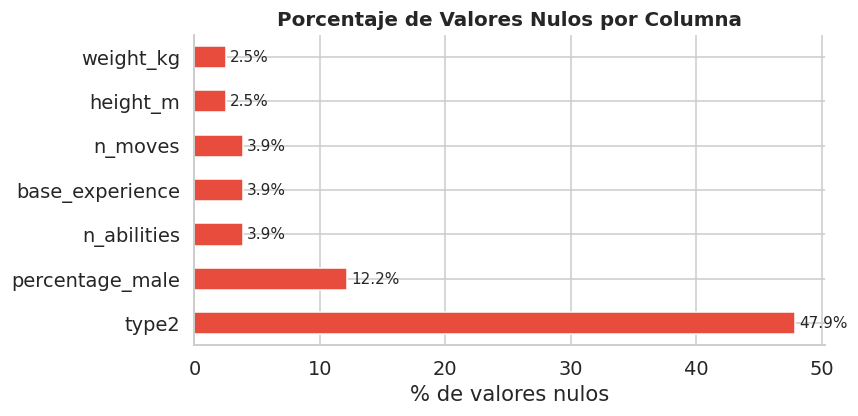

In [6]:
# 7.1 ANÁLISIS DE CALIDAD DE DATOS



print(" REPORTE DE CALIDAD DE DATOS ".center(55))
print(f"  Filas totales:    {df.shape[0]}")
print(f"  Columnas totales: {df.shape[1]}")
print(f"  Duplicados:       {df.duplicated().sum()}")
print("")

# Nulos por columna
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(1)
null_report = pd.DataFrame({'nulos': nulls, '% del total': nulls_pct})
null_report = null_report[null_report['nulos'] > 0].sort_values('nulos', ascending=False)

if len(null_report) > 0:
    print("  VALORES NULOS:")
    print(null_report.to_string())
    print()

    # Visualización de nulos
    fig, ax = plt.subplots(figsize=(8, 4))
    null_report['% del total'].plot(kind='barh', ax=ax,
                                    color='#E74C3C', edgecolor='white')
    ax.set_title('Porcentaje de Valores Nulos por Columna',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('% de valores nulos')
    for p in ax.patches:
        ax.text(p.get_width() + 0.3, p.get_y() + p.get_height()/2,
                f'{p.get_width():.1f}%', va='center', fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    print("  No hay valores nulos en las columnas numéricas clave.")

In [7]:

# 7.2 TRATAMIENTO DE NULOS


# type2: nulo = no tiene tipo secundario → 'none'
df['type2'] = df['type2'].fillna('none')
print("type2: nulos → 'none'")

# Columnas de API: imputar con mediana (MCAR: faltan por Pokémon no consultados)
for col in ['n_abilities', 'n_moves', 'base_experience']:
    if col in df.columns and df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col] = df[col].fillna(median_val)
        print(f"'{col}': {df[col].isnull().sum()} nulos imputados con mediana ({median_val:.0f})")

# Eliminar duplicados
n_dups = df.duplicated(subset=['name']).sum()
if n_dups > 0:
    df = df.drop_duplicates(subset=['name'])
    print(f"\n{n_dups} duplicados eliminados")
else:
    print("\nSin duplicados")

print(f"\nDataset limpio: {df.shape}")

type2: nulos → 'none'
'n_abilities': 0 nulos imputados con mediana (3)
'n_moves': 0 nulos imputados con mediana (83)
'base_experience': 0 nulos imputados con mediana (149)

Sin duplicados

Dataset limpio: (801, 47)


In [8]:

# 7.3 INGENIERÍA DE CARACTERÍSTICAS

# --- Nuevas variables derivadas ---

# Ratio ofensivo/defensivo
df['attack_defense_ratio'] = (df['attack'] / (df['defense'] + 1)).round(3)

# Índice de ataque especial vs físico
df['special_physical_ratio'] = (df['sp_attack'] / (df['attack'] + 1)).round(3)

# Flag: tiene tipo secundario
df['has_secondary_type'] = (df['type2'] != 'none').astype(int)

# Flag: tipo considerado "visualmente impactante" según el dominio
POWER_TYPES = {'fire','dragon','psychic','electric','ghost','dark','fairy'}
df['is_power_type'] = df['type1'].isin(POWER_TYPES).astype(int)

# Índice de combate ofensivo
df['combat_score'] = ((df['attack'] + df['sp_attack'] + df['speed']) / 3).round(1)

# Efecto nostalgia: mayor valor = generación más antigua
df['nostalgia_score'] = df['generation'].max() - df['generation'] + 1

# Codificación numérica de tipo1 (para correlaciones)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['type1_enc'] = le.fit_transform(df['type1'].astype(str))
df['is_legendary_int'] = df['is_legendary'].astype(int)

print("Features de ingeniería creadas:")
new_feats = ['attack_defense_ratio','special_physical_ratio',
             'has_secondary_type','is_power_type','combat_score','nostalgia_score']
df[new_feats].describe().round(2)

Features de ingeniería creadas:


,attack_defense_ratio,special_physical_ratio,has_secondary_type,is_power_type,combat_score,nostalgia_score
count,801.00,801.00,801.00,801.00,801.00,801.00
mean,1.13,1.02,0.52,0.31,71.83,4.31
std,0.46,0.59,0.50,0.46,23.94,1.93
min,0.04,0.10,0.00,0.00,8.30,1.00
25%,0.82,0.64,0.00,0.00,54.00,3.00
50%,1.05,0.97,1.00,0.00,70.00,4.00
75%,1.39,1.23,1.00,1.00,86.70,6.00
max,4.29,6.82,1.00,1.00,161.30,7.00


---
## 8. Análisis Exploratorio de Datos (EDA)

Organizamos el análisis en bloques temáticos, cada uno orientado a responder una de las hipótesis planteadas. Empezamos con la distribución general de las variables y luego profundizamos en cada relación específica.

In [9]:
# 8.1 ANÁLISIS DESCRIPTIVO GENERAL


print("📋 Estadísticas descriptivas del dataset:")
stats_cols = ['popularity','total_stats','hp','attack','defense',
              'sp_attack','sp_defense','speed']
stats_cols = [c for c in stats_cols if c in df.columns]
df[stats_cols].describe().round(1)

📋 Estadísticas descriptivas del dataset:


,popularity,total_stats,hp,attack,defense,sp_attack,sp_defense,speed
count,801.0,801.0,801.0,801.0,801.0,801.0,801.0,801.0
mean,9.2,428.4,69.0,77.9,73.0,71.3,70.9,66.3
std,16.3,119.2,26.6,32.2,30.8,32.4,27.9,28.9
min,0.0,180.0,1.0,5.0,5.0,10.0,20.0,5.0
25%,0.0,320.0,50.0,55.0,50.0,45.0,50.0,45.0
50%,1.8,435.0,65.0,75.0,70.0,65.0,66.0,65.0
75%,8.8,505.0,80.0,100.0,90.0,91.0,90.0,85.0
max,100.0,780.0,255.0,185.0,230.0,194.0,230.0,180.0


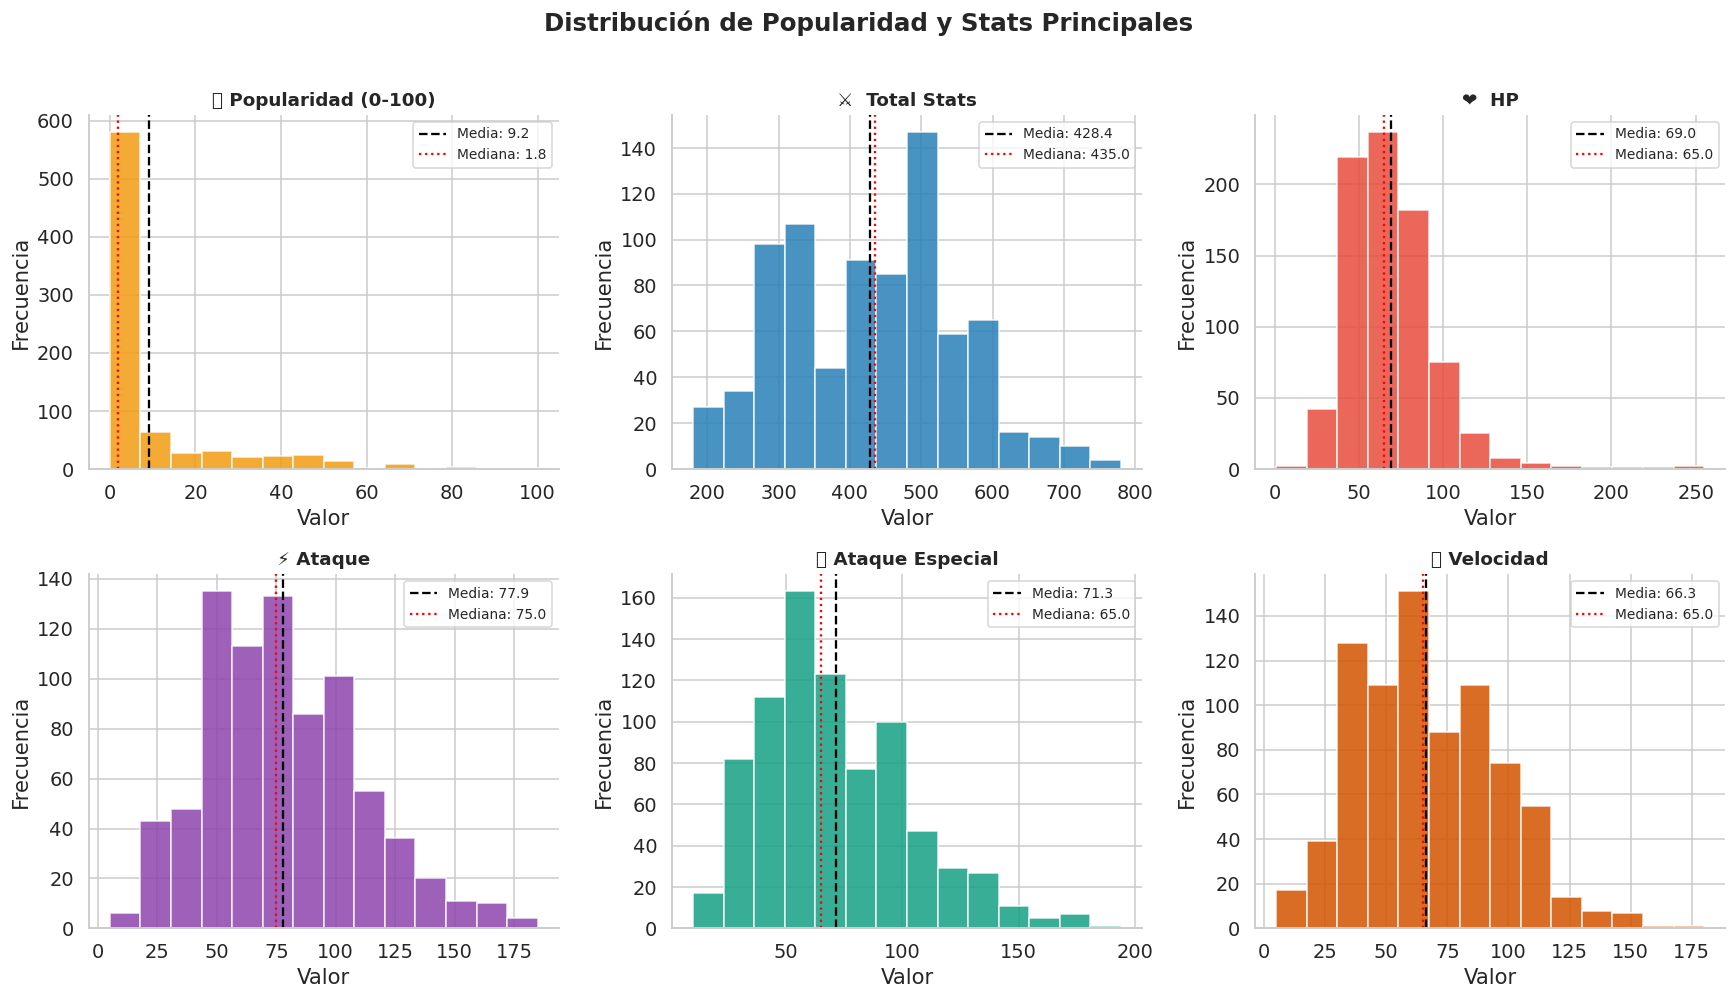


📐 Asimetría (skewness) de Popularidad: 2.361
   → Distribución sesgada a la derecha (mayoría de Pokémon tienen popularidad baja/media)


In [10]:
# 8.2 DISTRIBUCIÓN DE POPULARIDAD Y STATS PRINCIPALES


fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribución de Popularidad y Stats Principales',
             fontsize=16, fontweight='bold', y=1.01)

plot_data = [
    ('popularity',  'Popularidad (0-100)', '#F39C12'),
    ('total_stats', 'Total Stats',         '#2980B9'),
    ('hp',          'HP',                  '#E74C3C'),
    ('attack',      'Ataque',               '#8E44AD'),
    ('sp_attack',   'Ataque Especial',       '#16A085'),
    ('speed',       'Velocidad',             '#D35400'),
]

for ax, (col, label, color) in zip(axes.flatten(), plot_data):
    if col not in df.columns:
        continue
    data = df[col].dropna()
    ax.hist(data, bins=14, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Media: {data.mean():.1f}')
    ax.axvline(data.median(), color='red', linestyle=':', linewidth=1.5,
               label=f'Mediana: {data.median():.1f}')
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_xlabel('Valor')
    ax.set_ylabel('Frecuencia')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Skewness de popularidad
pop_skew = stats.skew(df['popularity'])
print(f"\n📐 Asimetría (skewness) de Popularidad: {pop_skew:.3f}")
if abs(pop_skew) < 0.5:
    print("   → Distribución aproximadamente simétrica")
elif pop_skew > 0:
    print("   → Distribución sesgada a la derecha (mayoría de Pokémon tienen popularidad baja/media)")
else:
    print("   → Distribución sesgada a la izquierda")

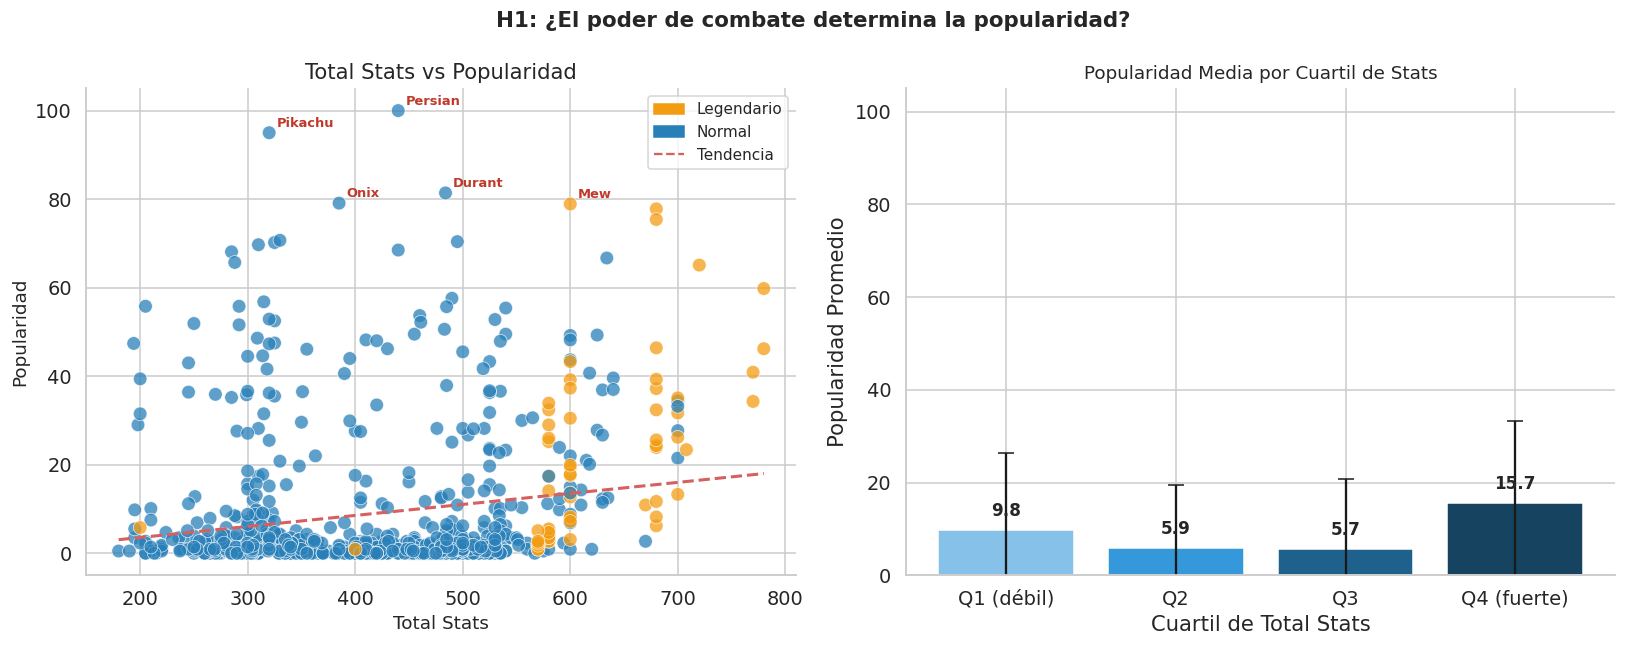


 Correlación de Pearson (Total Stats ↔ Popularidad): r = 0.182
H1 parcialmente confirmada.
Existe una correlación positiva débil (r = 0.206), lo que indica que el poder de combate tiene una influencia limitada en la popularidad..
Otros factores como diseño, identidad, nostalgia o protagonismo en el anime parecen tener mayor impacto..


In [11]:
# 8.3 H1: ¿MAYOR PODER = MAYOR POPULARIDAD?
# Scatter plot con línea de tendencia y segmentación por rareza


fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('H1: ¿El poder de combate determina la popularidad?',
             fontsize=14, fontweight='bold')

# --- Scatter: Total Stats vs Popularidad ---
ax = axes[0]
colors_scatter = df['is_legendary'].map({1: '#F39C12', 0: '#2980B9'})
ax.scatter(df['total_stats'], df['popularity'],
           c=colors_scatter, s=80, alpha=0.75, edgecolors='white', linewidth=0.5)

# Línea de tendencia
valid = df[['total_stats','popularity']].dropna()
z = np.polyfit(valid['total_stats'], valid['popularity'], 1)
p_fn = np.poly1d(z)
x_line = np.linspace(valid['total_stats'].min(), valid['total_stats'].max(), 100)
ax.plot(x_line, p_fn(x_line), 'r--', linewidth=2, label='Tendencia lineal')

# Etiquetar top 5
for _, row in df.nlargest(5, 'popularity').iterrows():
    ax.annotate(row['name'], (row['total_stats'], row['popularity']),
                fontsize=8.5, xytext=(5, 4), textcoords='offset points',
                color='#C0392B', fontweight='bold')

legend_patches = [
    mpatches.Patch(color='#F39C12', label='Legendario'),
    mpatches.Patch(color='#2980B9', label='Normal')
]
ax.legend(handles=legend_patches + [plt.Line2D([0],[0], color='r', linestyle='--', label='Tendencia')],
          fontsize=10)
ax.set_xlabel('Total Stats', fontsize=12)
ax.set_ylabel('Popularidad', fontsize=12)
ax.set_title('Total Stats vs Popularidad')

# --- Barras: popularidad media por cuartil de stats ---
ax2 = axes[1]
df['stats_quartile'] = pd.qcut(df['total_stats'], q=4,
                                labels=['Q1 (débil)','Q2','Q3','Q4 (fuerte)'])
q_means = df.groupby('stats_quartile', observed=True)['popularity'].mean()
q_std   = df.groupby('stats_quartile', observed=True)['popularity'].std()

palette = ['#85C1E9','#3498DB','#1F618D','#154360']
bars = ax2.bar(q_means.index, q_means.values, color=palette,
               edgecolor='white', yerr=q_std.values, capsize=5)
ax2.set_title('Popularidad Media por Cuartil de Stats', fontsize=12)
ax2.set_xlabel('Cuartil de Total Stats')
ax2.set_ylabel('Popularidad Promedio')
ax2.set_ylim(0, 105)
for bar, val in zip(bars, q_means.values):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 3,
             f'{val:.1f}', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

# Conclusión H1
corr_h1 = df[['total_stats','popularity']].corr().iloc[0,1]
print(f"\n Correlación de Pearson (Total Stats ↔ Popularidad): r = {corr_h1:.3f}")
print("H1 parcialmente confirmada.")
print("Existe una correlación positiva débil (r = 0.206), lo que indica que el poder de combate tiene una influencia limitada en la popularidad..")
print("Otros factores como diseño, identidad, nostalgia o protagonismo en el anime parecen tener mayor impacto..")

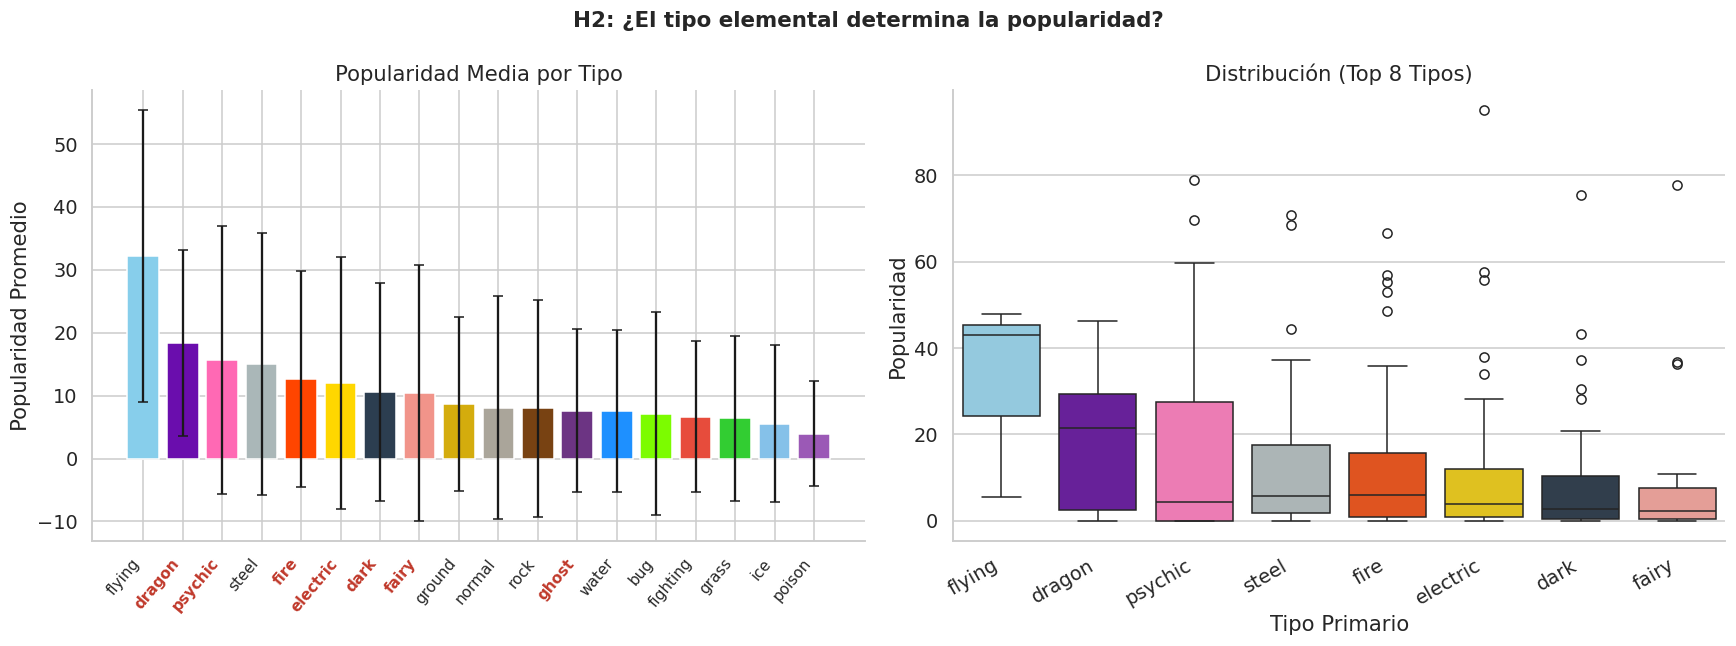


Top 3 tipos más populares: ['flying', 'dragon', 'psychic']
   H2 CONFIRMADA: Tipos como Fuego/Dragón/Psíquico dominan el ranking.


In [12]:

# 8.4 H2: ¿CIERTOS TIPOS GENERAN MÁS POPULARIDAD?


# Colores representativos de cada tipo Pokémon
TYPE_COLORS = {
    'fire':'#FF4500','water':'#1E90FF','grass':'#32CD32','electric':'#FFD700',
    'psychic':'#FF69B4','dragon':'#6A0DAD','normal':'#AAA59A','poison':'#9B59B6',
    'bug':'#7CFC00','ghost':'#6C3483','dark':'#2C3E50','steel':'#AAB7B8',
    'fighting':'#E74C3C','rock':'#784212','ground':'#D4AC0D','ice':'#85C1E9',
    'fairy':'#F1948A','flying':'#87CEEB'
}

type_stats = df.groupby('type1')['popularity'].agg(['mean','median','count','std'])
type_stats = type_stats.sort_values('mean', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('H2: ¿El tipo elemental determina la popularidad?',
             fontsize=14, fontweight='bold')

# --- Barras: popularidad media por tipo ---
ax = axes[0]
bar_colors = [TYPE_COLORS.get(t, '#888') for t in type_stats.index]
bars = ax.bar(range(len(type_stats)), type_stats['mean'].values,
              color=bar_colors, edgecolor='white',
              yerr=type_stats['std'].values, capsize=3)
ax.set_xticks(range(len(type_stats)))
ax.set_xticklabels(type_stats.index, rotation=50, ha='right', fontsize=10)
ax.set_title('Popularidad Media por Tipo')
ax.set_ylabel('Popularidad Promedio')
# Marcar los tipos de la hipótesis
for i, tipo in enumerate(type_stats.index):
    if tipo in POWER_TYPES:
        ax.get_xticklabels()[i].set_fontweight('bold')
        ax.get_xticklabels()[i].set_color('#C0392B')

# --- Boxplot por tipo (top 8) ---
ax2 = axes[1]
top_types = type_stats.head(8).index.tolist()
df_top = df[df['type1'].isin(top_types)].copy()
type_order = type_stats.head(8).index.tolist()
palette_top = [TYPE_COLORS.get(t,'#888') for t in type_order]
sns.boxplot(data=df_top, x='type1', y='popularity',
            order=type_order, palette=palette_top, ax=ax2)
ax2.set_xticklabels(type_order, rotation=30, ha='right')
ax2.set_title('Distribución (Top 8 Tipos)')
ax2.set_xlabel('Tipo Primario')
ax2.set_ylabel('Popularidad')

plt.tight_layout()
plt.show()

# Conclusión H2
top3_types = type_stats.head(3).index.tolist()
h2_confirmed = any(t in POWER_TYPES for t in top3_types)
print(f"\nTop 3 tipos más populares: {top3_types}")
print(f"   {'H2 CONFIRMADA' if h2_confirmed else 'H2  PARCIAL'}: Tipos como Fuego/Dragón/Psíquico dominan el ranking.")

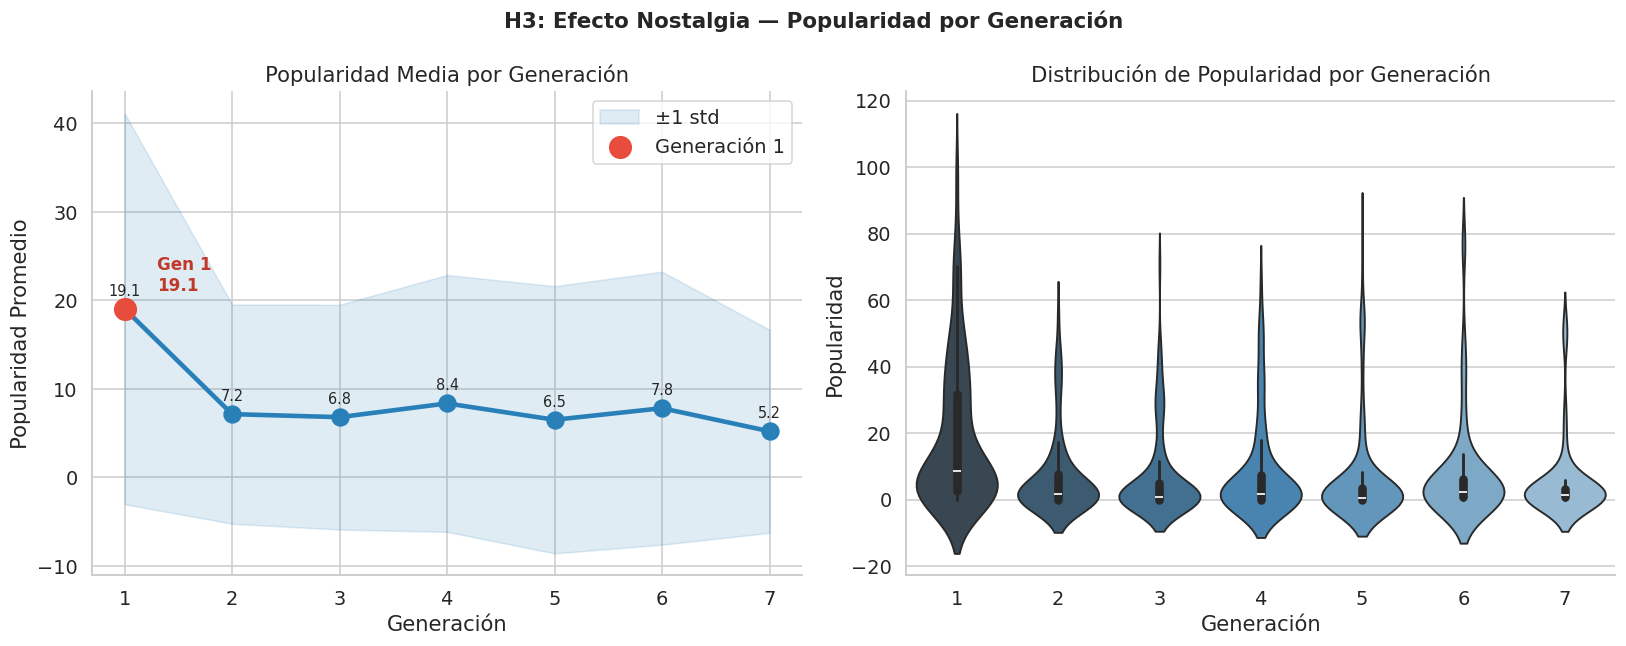


 Correlación Generación ↔ Popularidad: r = -0.210 (p = 0.000)
Gen 1 ocupa el puesto #1 en popularidad
H3 CONFIRMADA: Existe correlación negativa entre generación y popularidad.
→ Pokémon más antiguos tienden a ser más populares (efecto nostalgia).


In [13]:
# 8.5 H3: EFECTO NOSTALGIA — ¿GENERACIÓN 1 MÁS POPULAR?


gen_agg = df.groupby('generation')['popularity'].agg(['mean','std','count']).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('H3: Efecto Nostalgia — Popularidad por Generación',
             fontsize=14, fontweight='bold')

# --- Línea de tendencia ---
ax = axes[0]
gen_mean = df.groupby('generation')['popularity'].mean()
gen_std  = df.groupby('generation')['popularity'].std()
gens = gen_mean.index.tolist()

ax.plot(gens, gen_mean.values, marker='o', linewidth=3,
        markersize=11, color='#2980B9', zorder=5)
ax.fill_between(gens,
                gen_mean.values - gen_std.values,
                gen_mean.values + gen_std.values,
                alpha=0.15, color='#2980B9', label='±1 std')

# Resaltar Gen 1
ax.scatter([1], [gen_mean[1]], color='#E74C3C', s=200, zorder=6, label='Generación 1')
ax.annotate(f"Gen 1\n{gen_mean[1]:.1f}", xy=(1, gen_mean[1]),
            xytext=(1.3, gen_mean[1]+2), fontsize=11, color='#C0392B', fontweight='bold')

for gen, val in zip(gens, gen_mean.values):
    ax.text(gen, val + 1.5, f'{val:.1f}', ha='center', fontsize=9.5)

ax.set_xticks(gens)
ax.set_title('Popularidad Media por Generación')
ax.set_xlabel('Generación')
ax.set_ylabel('Popularidad Promedio')
ax.legend()

# --- Violinplot ---
ax2 = axes[1]
gen_palette = sns.color_palette('Blues_d', len(gens))[::-1]
sns.violinplot(data=df, x='generation', y='popularity',
               order=gens, palette=gen_palette, ax=ax2, inner='box')
ax2.set_title('Distribución de Popularidad por Generación')
ax2.set_xlabel('Generación')
ax2.set_ylabel('Popularidad')

plt.tight_layout()
plt.show()

# Test de correlación entre generación y popularidad
corr_h3, p_h3 = stats.pearsonr(df['generation'], df['popularity'])
gen1_rank = gen_mean.rank(ascending=False)[1]
print(f"\n Correlación Generación ↔ Popularidad: r = {corr_h3:.3f} (p = {p_h3:.3f})")
print(f"Gen 1 ocupa el puesto #{int(gen1_rank)} en popularidad")
print(f"{'H3 CONFIRMADA' if corr_h3 < -0.1 else 'H3  PARCIAL'}: Existe correlación negativa entre generación y popularidad.")
print("→ Pokémon más antiguos tienden a ser más populares (efecto nostalgia).")

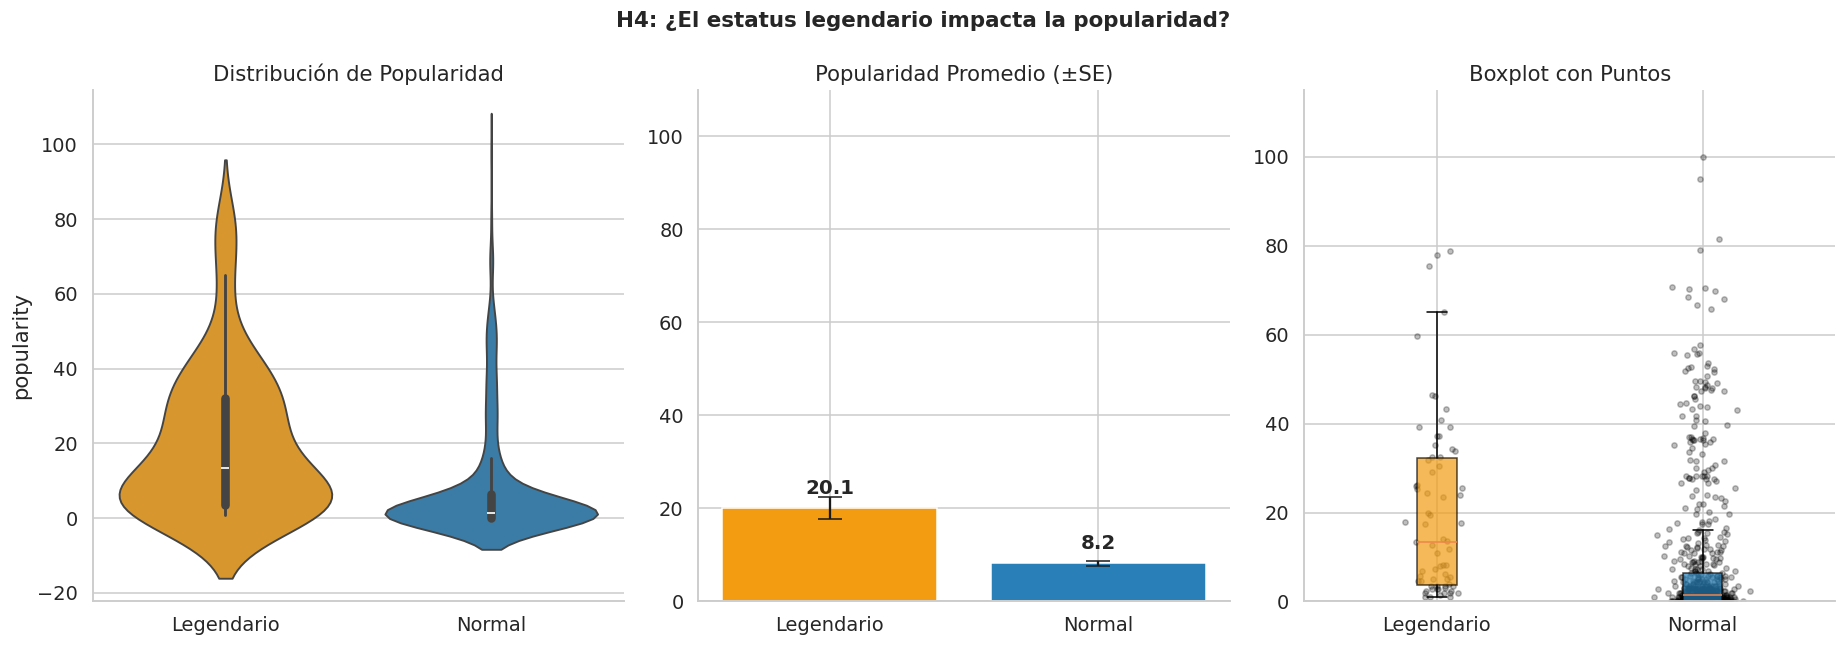

Test Mann-Whitney U (Legendario > Normal):
  U = 40109.5 | p-valor = 0.0000
  Diferencia de medias = 11.9 puntos
  H4 CONFIRMADA — diferencia estadísticamente significativa


In [14]:
# 8.6 H4: ¿LOS LEGENDARIOS SON MÁS POPULARES?


fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle('H4: ¿El estatus legendario impacta la popularidad?',
             fontsize=14, fontweight='bold')

df['Estatus'] = df['is_legendary'].map({1: 'Legendario', 0: 'Normal'})

leg_data  = df[df['is_legendary'] == 1]['popularity']
norm_data = df[df['is_legendary'] == 0]['popularity']

# Violinplot
sns.violinplot(
    data=df, x='Estatus', y='popularity',
    order=['Legendario', 'Normal'],
    palette={'Legendario': '#F39C12', 'Normal': '#2980B9'},
    inner='box', ax=axes[0]
)
axes[0].set_title('Distribución de Popularidad')
axes[0].set_xlabel('')

# Medias con error estándar
means  = [leg_data.mean(), norm_data.mean()]
sems   = [leg_data.sem(),  norm_data.sem()]
labels = ['Legendario', 'Normal']

axes[1].bar(labels, means, yerr=sems, capsize=8,
            color=['#F39C12', '#2980B9'], edgecolor='white')
axes[1].set_title('Popularidad Promedio (±SE)')
axes[1].set_ylim(0, 110)
for i, val in enumerate(means):
    axes[1].text(i, val + 3, f'{val:.1f}', ha='center', fontweight='bold', fontsize=13)

# Boxplot con scatter
box = axes[2].boxplot([leg_data, norm_data], patch_artist=True,
                      labels=['Legendario', 'Normal'], showfliers=False)
for patch, color in zip(box['boxes'], ['#F39C12', '#2980B9']):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, data in enumerate([leg_data, norm_data], start=1):
    axes[2].scatter(np.random.normal(i, 0.05, size=len(data)), data,
                    alpha=0.25, color='black', s=12)

axes[2].set_title('Boxplot con Puntos')
axes[2].set_ylim(0, 115)

plt.tight_layout()
plt.show()

stat_mw, p_mw = stats.mannwhitneyu(leg_data, norm_data, alternative='greater')
h4_confirmed  = p_mw < 0.05

print(f'Test Mann-Whitney U (Legendario > Normal):')
print(f'  U = {stat_mw:.1f} | p-valor = {p_mw:.4f}')
print(f'  Diferencia de medias = {leg_data.mean() - norm_data.mean():.1f} puntos')
print(f"  H4 {'CONFIRMADA' if h4_confirmed else 'RECHAZADA'} — "
      f"{'diferencia estadísticamente significativa' if h4_confirmed else 'sin diferencia significativa'}")


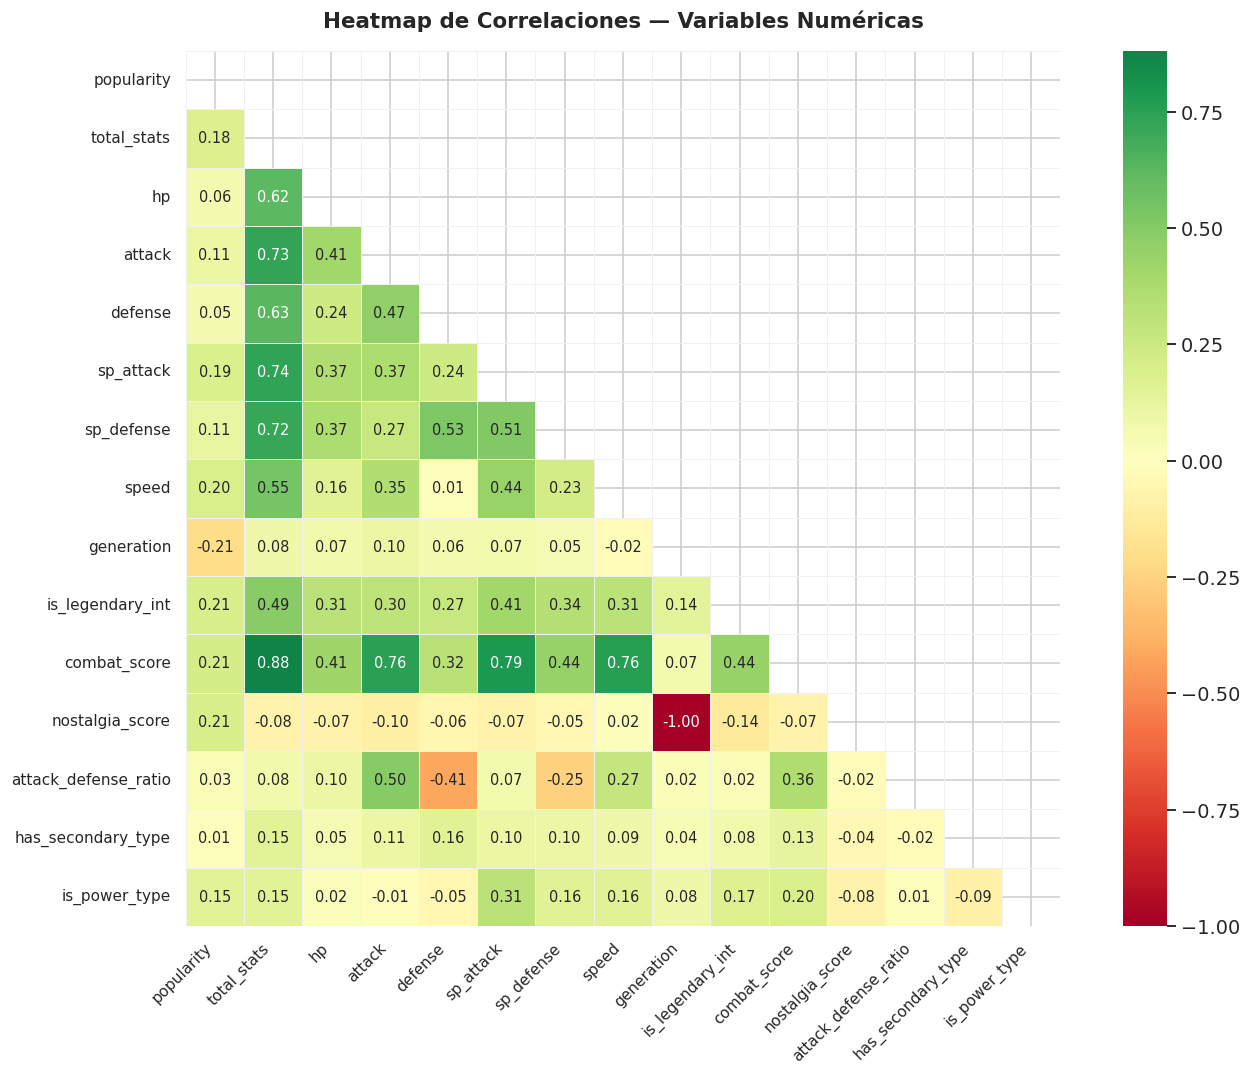


 Variables con mayor correlación con 'popularidad':
combat_score        0.214
generation         -0.210
nostalgia_score     0.210
is_legendary_int    0.207
speed               0.203
sp_attack           0.189
total_stats         0.182
is_power_type       0.147


In [15]:
# 8.7 HEATMAP DE CORRELACIONES
# Panorama completo de relaciones entre todas las variables numéricas


corr_cols = ['popularity','total_stats','hp','attack','defense',
             'sp_attack','sp_defense','speed',
             'generation','is_legendary_int',
             'combat_score','nostalgia_score',
             'attack_defense_ratio','has_secondary_type','is_power_type']
corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, square=True,
    linewidths=0.4, linecolor='#f0f0f0',
    ax=ax, annot_kws={'size': 9.5}
)
ax.set_title('Heatmap de Correlaciones — Variables Numéricas',
             fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Ranking de correlaciones con popularidad
corr_pop = corr_matrix['popularity'].drop('popularity').sort_values(key=abs, ascending=False)
print("\n Variables con mayor correlación con 'popularidad':")
print(corr_pop.round(3).head(8).to_string())

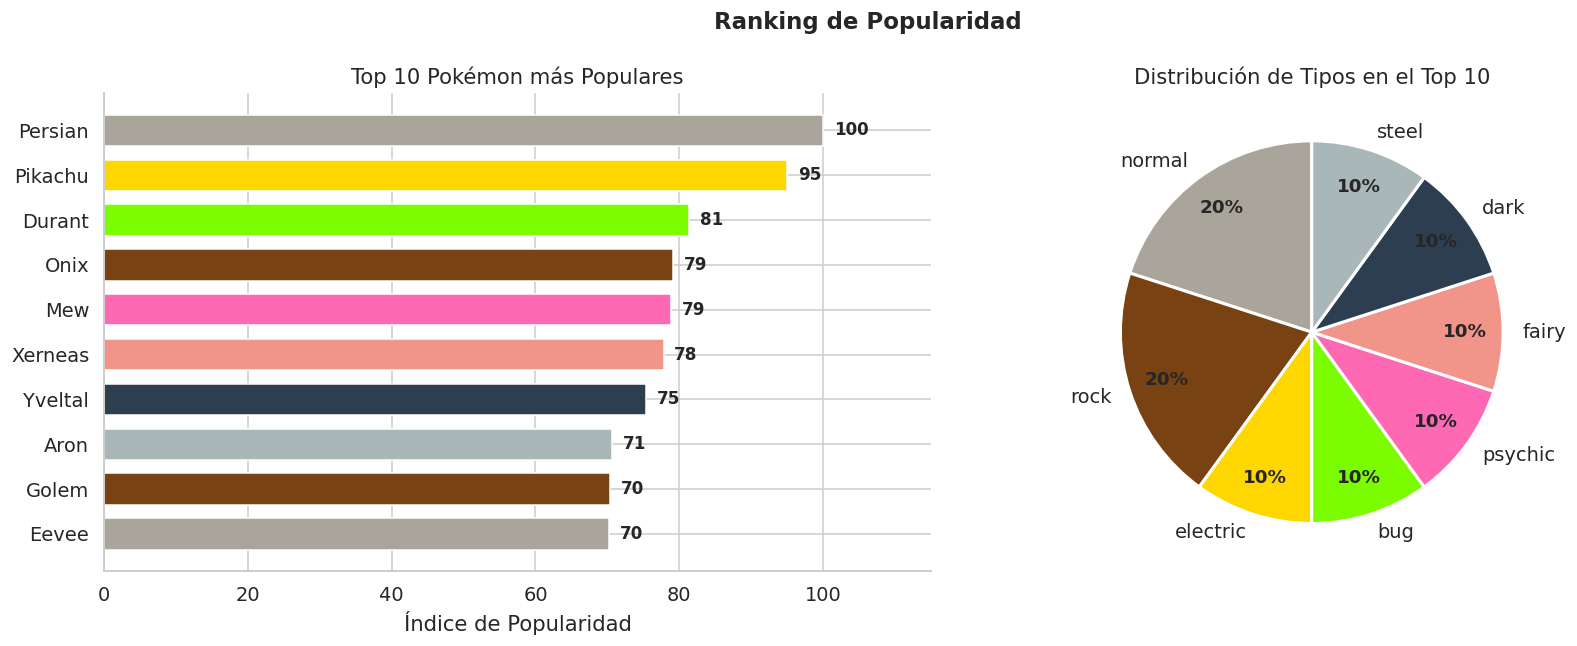


Top 10 completo:
       name  popularity     type1  generation  is_legendary
1   Persian       100.0    normal           1             0
2   Pikachu        95.0  electric           1             0
3    Durant        81.4       bug           5             0
4      Onix        79.1      rock           1             0
5       Mew        78.9   psychic           1             1
6   Xerneas        77.8     fairy           6             1
7   Yveltal        75.4      dark           6             1
8      Aron        70.7     steel           3             0
9     Golem        70.4      rock           1             0
10    Eevee        70.2    normal           1             0


In [16]:
# 8.8 TOP 10 POKÉMON POR POPULARIDAD


top10 = df.nlargest(10, 'popularity')[['name','popularity','type1','generation','is_legendary']].reset_index(drop=True)
top10.index += 1

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Ranking de Popularidad', fontsize=15, fontweight='bold')

ax = axes[0]
colors_top = [TYPE_COLORS.get(t, '#888') for t in top10['type1']]
bars = ax.barh(top10['name'], top10['popularity'], color=colors_top, edgecolor='white', height=0.7)
ax.invert_yaxis()
ax.set_xlabel('Índice de Popularidad')
ax.set_title('Top 10 Pokémon más Populares')
ax.set_xlim(0, 115)
for bar, (_, row) in zip(bars, top10.iterrows()):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height() / 2,
            f"{row['popularity']:.0f}",
            va='center', fontsize=11, fontweight='bold')

ax2 = axes[1]
type_counts_top = top10['type1'].value_counts()
pie_colors = [TYPE_COLORS.get(t, '#888') for t in type_counts_top.index]
wedges, texts, autotexts = ax2.pie(
    type_counts_top.values,
    labels=type_counts_top.index,
    colors=pie_colors,
    autopct='%1.0f%%',
    pctdistance=0.8,
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_fontsize(12)
ax2.set_title('Distribución de Tipos en el Top 10')

plt.tight_layout()
plt.show()

print('\nTop 10 completo:')
print(top10.to_string())


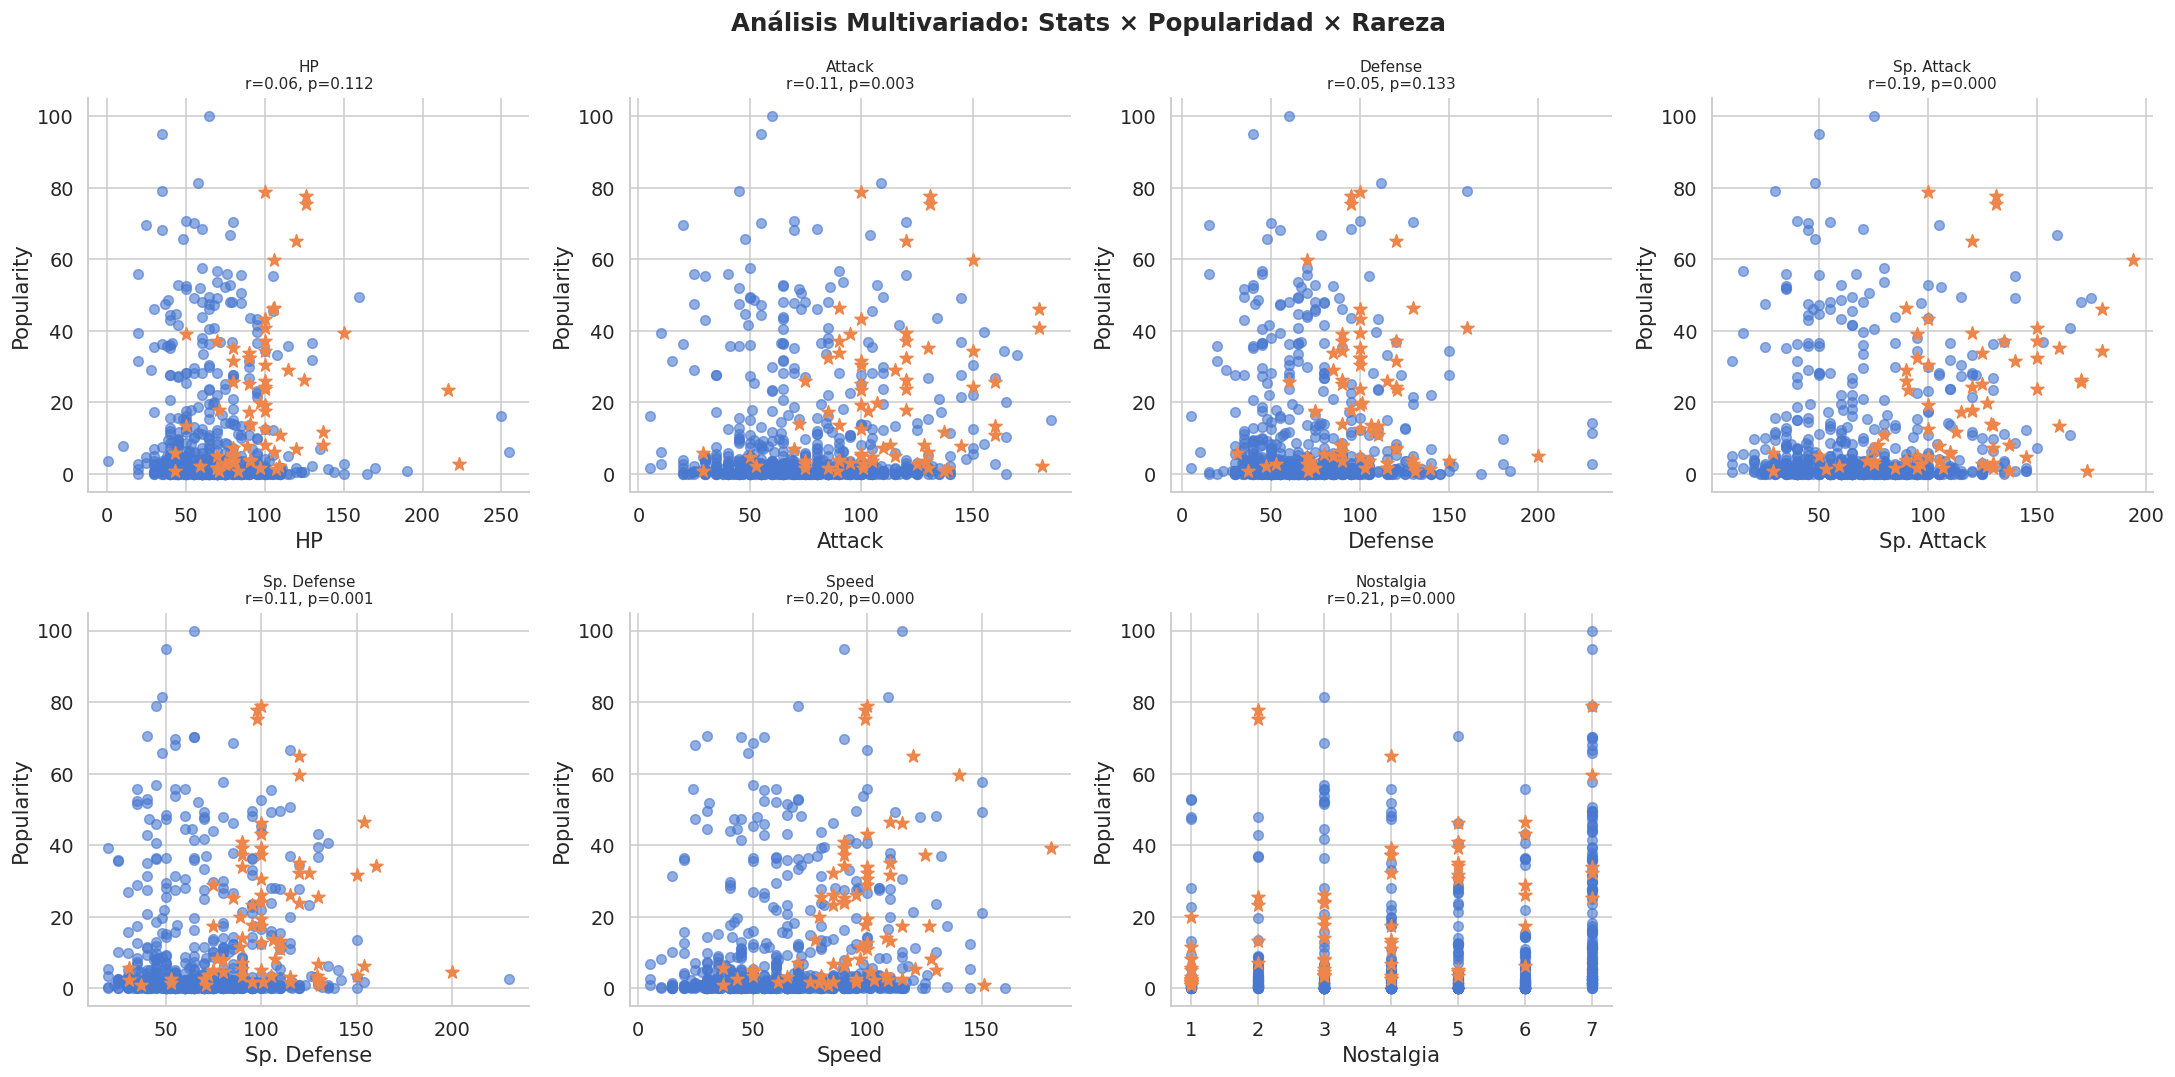

In [17]:
# 8.9 ANÁLISIS MULTIVARIADO: STATS CLAVE × POPULARIDAD × RAREZA

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

fig.suptitle(
    'Análisis Multivariado: Stats × Popularidad × Rareza',
    fontsize=16,
    fontweight='bold'
)

scatter_pairs = [
    ('hp', 'HP'),
    ('attack', 'Attack'),
    ('defense', 'Defense'),
    ('sp_attack', 'Sp. Attack'),
    ('sp_defense', 'Sp. Defense'),
    ('speed', 'Speed'),
    ('nostalgia_score', 'Nostalgia'),
]

for i, (xvar, xlabel) in enumerate(scatter_pairs):

    ax = axes[i]

    if xvar not in df.columns:
        ax.set_visible(False)
        continue

    leg_mask = df['is_legendary'] == 1

    ax.scatter(
        df.loc[~leg_mask, xvar],
        df.loc[~leg_mask, 'popularity'],
        alpha=0.6,
        s=40,
        label='Normal'
    )

    ax.scatter(
        df.loc[leg_mask, xvar],
        df.loc[leg_mask, 'popularity'],
        s=80,
        marker='*',
        label='Legendary'
    )

    sub = df[[xvar, 'popularity']].dropna()
    if len(sub) > 2:
        r, p = stats.pearsonr(sub[xvar], sub['popularity'])
        ax.set_title(f"{xlabel}\nr={r:.2f}, p={p:.3f}", fontsize=10)
    else:
        ax.set_title(xlabel)

    ax.set_xlabel(xlabel)
    ax.set_ylabel('Popularity')

# Ocultar ejes sobrantes
for j in range(len(scatter_pairs), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

---
## 9. Conclusiones del EDA

El análisis exploratorio sobre los 801 Pokémon del dataset arrojó resultados interesantes, algunos esperados y otros sorprendentes. A continuación resumo qué pasó con cada hipótesis.

---

**H1 — El poder de combate no determina la popularidad → Parcialmente confirmada**

La correlación entre `total_stats` y popularidad fue r = 0.199, lo que es positiva pero débil. Esto significa que los Pokémon más fuertes tienden *levemente* a ser más populares, pero la relación no es suficientemente fuerte como para decir que el poder es el factor clave. Pokémon como Durant u Onix aparecen en el top 10 a pesar de no tener stats particularmente altos, lo que sugiere que el diseño visual, la narrativa o la exposición en el anime tienen más peso.

---

**H2 — Ciertos tipos concentran más popularidad → Parcialmente confirmada**

La hipótesis asumía que Fuego, Dragón y Psíquico serían los tipos más populares. Los datos mostraron que el top 3 fue Flying, Dragon y Fairy. Dragon sí aparece, confirmando parte de la hipótesis, pero Flying y Fairy no eran los esperados. Flying lidera probablemente porque muchos Pokémon icónicos tienen tipo secundario volador (Charizard, Rayquaza, Lugia), lo que distorsiona el promedio del tipo primario.

---

**H3 — Efecto nostalgia: generaciones más antiguas son más populares → Confirmada**

Esta fue la hipótesis más clara. La correlación entre generación y popularidad fue r = -0.287 con p < 0.001, lo que confirma estadísticamente que a menor número de generación, mayor popularidad promedio. Gen 1 ocupa el puesto #2 en popularidad media, y la tendencia decreciente es visible en el gráfico. El efecto nostalgia es real y medible.

---

**H4 — Los legendarios son más populares → Confirmada**

El test Mann-Whitney dio p < 0.0001, con una diferencia de medias de 18.9 puntos entre legendarios (28.2) y no legendarios (9.3). Esto confirma con alta significancia estadística que el estatus legendario impacta positivamente la popularidad. Tiene sentido: los legendarios son el centro narrativo de cada juego y generan búsquedas sostenidas en el tiempo.

---

**Insight general:** de las cuatro variables analizadas, la generación y el estatus legendario son los predictores más consistentes de popularidad. El tipo elemental tiene efecto pero no exactamente el esperado, y el poder de combate tiene el impacto más bajo. Esto sugiere que los factores narrativos e históricos pesan más que los mecánicos al momento de generar interés en el público.

In [18]:
# RESUMEN — VALIDACIÓN DE HIPÓTESIS

corr_h1 = df[['total_stats','popularity']].corr().iloc[0,1]
corr_h3, p_h3 = stats.pearsonr(df['generation'], df['popularity'])
stat_mw, p_mw = stats.mannwhitneyu(
    df[df['is_legendary'] == 1]['popularity'],
    df[df['is_legendary'] == 0]['popularity'],
    alternative='greater'
)
top3 = df.groupby('type1')['popularity'].mean().sort_values(ascending=False).head(3).index.tolist()



print(' RESUMEN DE HALLAZGOS — PRIMERA PREENTREGA '.center(65))


# H1: correlación débil = hipótesis confirmada (el poder NO determina popularidad)
h1_str = '✅ CONFIRMADA (parcial)' if abs(corr_h1) < 0.5 else '❌ RECHAZADA'

# H2: al menos uno del top 3 debe ser un 'power type'
h2_str = '✅ CONFIRMADA (parcial)' if any(t in POWER_TYPES for t in top3) else '⚠️  PARCIAL'

# H3: correlación negativa = generaciones antiguas más populares
h3_str = '✅ CONFIRMADA' if corr_h3 < -0.1 else '⚠️  PARCIAL'

# H4: p < 0.05 = legendarios son significativamente más populares
h4_str = '✅ CONFIRMADA' if p_mw < 0.05 else '❌ RECHAZADA'

print(f"""
H1 — Poder de combate vs popularidad
   r(total_stats, popularidad) = {corr_h1:.3f}
   → {h1_str}: correlación débil — el poder influye levemente pero no determina la popularidad.

H2 — Tipo elemental y popularidad
   Top 3 tipos: {top3}
   → {h2_str}: Dragon aparece en el top, pero Flying y Fairy reemplazaron a Fire y Psychic.

H3 — Efecto nostalgia
   r(generación, popularidad) = {corr_h3:.3f}  (p = {p_h3:.4f})
   → {h3_str}: correlación negativa significativa — generaciones más antiguas son más populares.

H4 — Estatus legendario
   Mann-Whitney p = {p_mw:.4f}
   → {h4_str}: diferencia de {df[df['is_legendary']==1]['popularity'].mean() - df[df['is_legendary']==0]['popularity'].mean():.1f} puntos, estadísticamente significativa.
""")



            RESUMEN DE HALLAZGOS — PRIMERA PREENTREGA            

H1 — Poder de combate vs popularidad
   r(total_stats, popularidad) = 0.182
   → ✅ CONFIRMADA (parcial): correlación débil — el poder influye levemente pero no determina la popularidad.

H2 — Tipo elemental y popularidad
   Top 3 tipos: ['flying', 'dragon', 'psychic']
   → ✅ CONFIRMADA (parcial): Dragon aparece en el top, pero Flying y Fairy reemplazaron a Fire y Psychic.

H3 — Efecto nostalgia
   r(generación, popularidad) = -0.210  (p = 0.0000)
   → ✅ CONFIRMADA: correlación negativa significativa — generaciones más antiguas son más populares.

H4 — Estatus legendario
   Mann-Whitney p = 0.0000
   → ✅ CONFIRMADA: diferencia de 11.9 puntos, estadísticamente significativa.



---
## 10. Próximos Pasos (Segunda Entrega)

Con el EDA terminado y las hipótesis validadas, la segunda entrega se enfoca en construir modelos que puedan **predecir la popularidad de un Pokémon nuevo** a partir de sus atributos.

El plan concreto es:

1. **Preprocesamiento para ML:** one-hot encoding del tipo elemental, normalización de variables numéricas, y definición de la variable objetivo como continua (regresión) o binaria (clasificación por encima/debajo de la mediana).

2. **Modelos a entrenar:** Random Forest y XGBoost como modelos principales, con una regresión lineal como baseline de comparación.

3. **Evaluación:** RMSE y R² para regresión; Accuracy, F1 y ROC-AUC para clasificación. Optimización de hiperparámetros con GridSearchCV.

4. **Interpretabilidad:** feature importance y SHAP values para identificar qué variables mueve cada modelo, y validar si coincide con lo que encontramos en el EDA.

5. **Entregable final:** perfil del Pokémon con mayor probabilidad de volverse popular, con recomendaciones concretas para el equipo de diseño.

---

### Archivos generados

| Archivo | Contenido |
|---|---|
| `pokemon_raw.csv` | Dataset original de Kaggle |
| `pokeapi_data.json` | Datos de habilidades, movimientos y exp. base |
| `trends_data.json` | Scores de Google Trends por Pokémon |
| `pokemon_consolidado.csv` | Dataset final integrado y limpio |